In [24]:
# importing core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# supressing warning for clear output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing tensorflow and keras
import tensorflow as tf
import keras
from keras import layers, models, optimizers, losses, metrics
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping

# importing other important libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# loading dataset
from keras.datasets import mnist

(x_train,  y_train), (x_test, y_test) = mnist.load_data()

print(f'Training sample: {x_train.shape[0]}')
print(f'Test sample: {x_test.shape[0]}')
print(f'Image size: {x_train.shape[1:]}')
print(f'Unique classes: {len(np.unique(y_train))}')

Training sample: 60000
Test sample: 10000
Image size: (28, 28)
Unique classes: 10


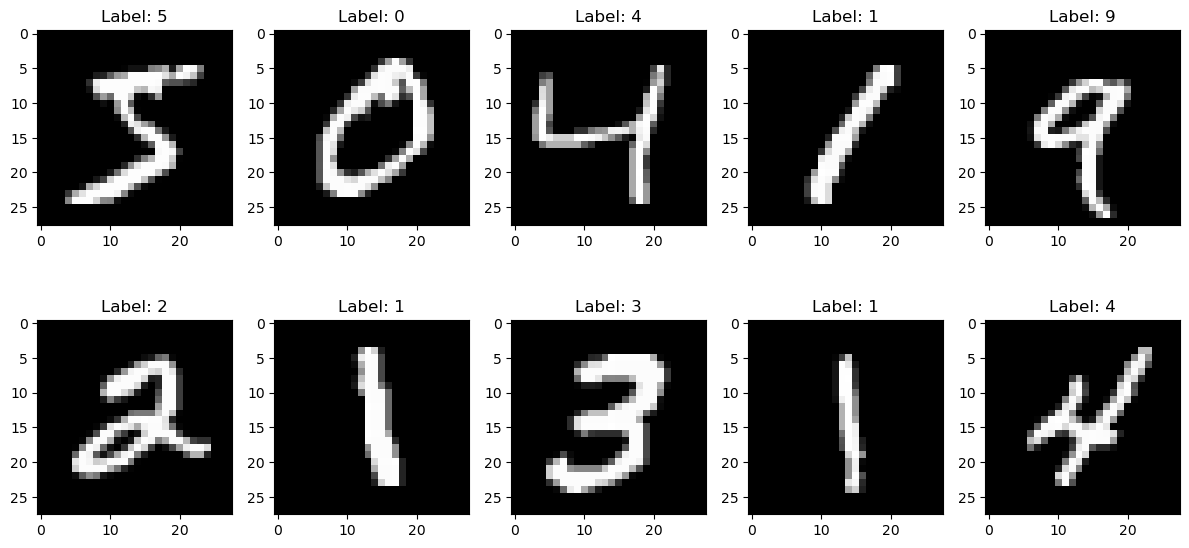

In [51]:
# Visualize samples
fig, axs = plt.subplots(2, 5, figsize=(12,6))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap = 'gray')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout()
plt.show()

In [5]:
# Flattening image 28x28
x_train_flat = x_train.reshape(x_train.shape[0],-1)
x_test_flat = x_test.reshape(x_test.shape[0],-1)

In [6]:
# Normalizing the data form [0-255] to [0-1]
x_train_norm = x_train_flat.astype('float32')/255.0
x_test_norm = x_test_flat.astype('float32')/255.0

print(f'Training data: \nOriginal range:{x_train_flat.min()} to {x_train_flat.max()}')
print(f'Normalized range:{x_train_norm.min()} to {x_train_norm.max()}')

Training data: 
Original range:0 to 255
Normalized range:0.0 to 1.0


In [7]:
# Converting numerical target column to categorical
y_train_categ = to_categorical(y_train, num_classes=10)
y_test_categ = to_categorical(y_test, num_classes=10)

In [8]:
# Building classifier for mnist dataset
model = keras.Sequential([
    layers.Dense(128, activation= 'relu',input_shape = (784,)),

    layers.Dense(64, name = 'hidden_layer'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),
    
    layers.Dense(10, activation='softmax', name = 'output_layer')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,642 (428.29 KB)

 Trainable params: 109,514 (427.79 KB)

 Non-trainable params: 128 (512.00 B)

In [9]:
# Compile the model
model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy']
              )

In [10]:
# Callback
model_checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor= 'val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Training the model
model_training = model.fit(
    x_train_norm,
    y_train_categ,
    epochs = 50,
    batch_size = 128,
    validation_split = 0.2,
    callbacks = [model_checkpoint, early_stopping],
    verbose = 1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8152 - loss: 0.6547
Epoch 1: val_loss improved from None to 0.17301, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9005 - loss: 0.3679 - val_accuracy: 0.9529 - val_loss: 0.1730
Epoch 2/50
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9556 - loss: 0.1504
Epoch 2: val_loss improved from 0.17301 to 0.11384, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9613 - loss: 0.1330 - val_accuracy: 0.9665 - val_loss: 0.1138
Epoch 3/50
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9733 - loss: 0.0912
Epoch 3: val_loss improved from 0.11384 to 0.09721, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9752 - loss: 0.0858 - val_accuracy: 0.9707 -

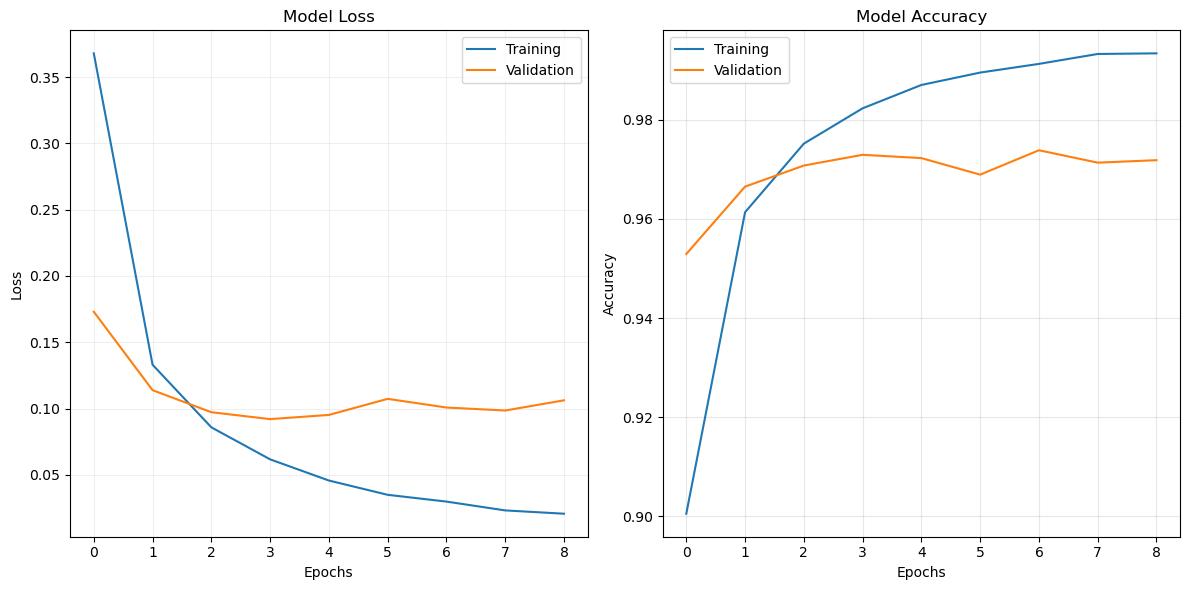

In [20]:
# Visualizing model training

fig, (axs1, axs2) = plt.subplots(1,2, figsize =(12,6))

axs1.plot(model_training.history['loss'], label = 'Training')
axs1.plot(model_training.history['val_loss'], label = "Validation")
axs1.set_xlabel('Epochs')
axs1.set_ylabel('Loss')
axs1.set_title('Model Loss')
axs1.legend()
axs1.grid(True, alpha = 0.2)

axs2.plot(model_training.history['accuracy'], label = 'Training')
axs2.plot(model_training.history['val_accuracy'], label = "Validation")
axs2.set_xlabel('Epochs')
axs2.set_ylabel('Accuracy')
axs2.set_title('Model Accuracy')
axs2.legend()
axs2.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test_categ, verbose = 0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss: 0.0827
Test accuracy: 0.9739


In [22]:
prediction_mnist = model.predict(x_test_norm, verbose = 0)

predicted_classes = np.argmax(prediction_mnist, axis = 1)
actual_classes = np.argmax(y_test_categ, axis = 1)

print(f'{predicted_classes[:10]}')
print(f"{y_train_categ[:10]}")

[7 2 1 0 4 1 4 9 5 9]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


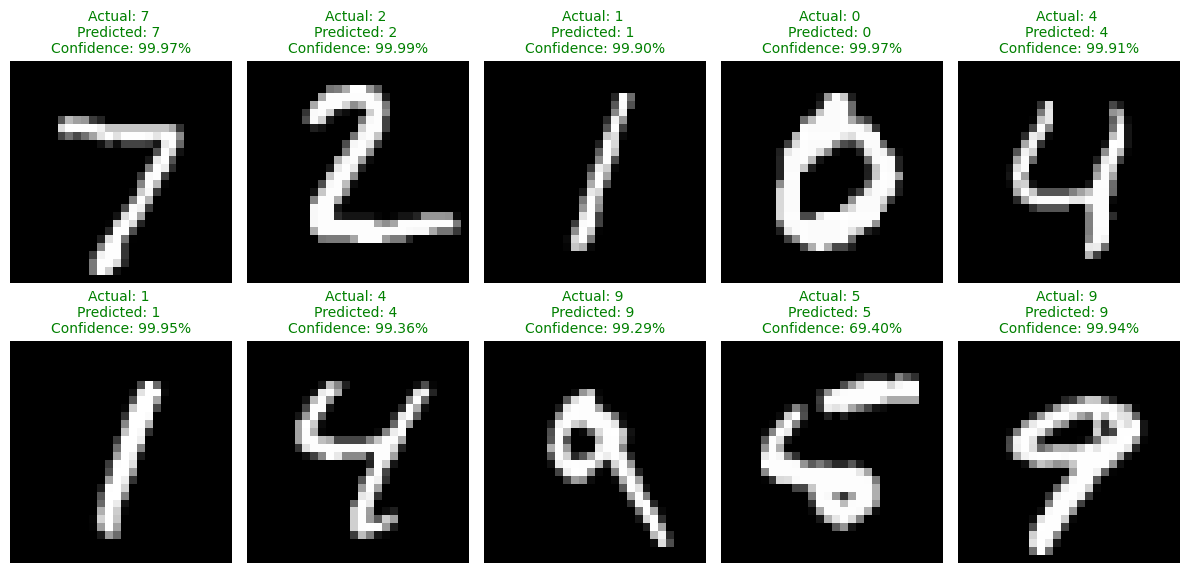

In [50]:
# Visualizing the predictions

fig, axes = plt.subplots(2, 5, figsize = (12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i], cmap= 'gray')
    color = 'green' if predicted_classes[i] == actual_classes[i] else 'red'
    Confidence =  np.max(prediction_mnist[i]) *100

    ax.set_title(f'Actual: {actual_classes[i]} \nPredicted: {predicted_classes[i]} \nConfidence: {Confidence:.2f}%', color = color, fontsize=10)
    ax.axis('off')
    
plt.tight_layout()
plt.show()

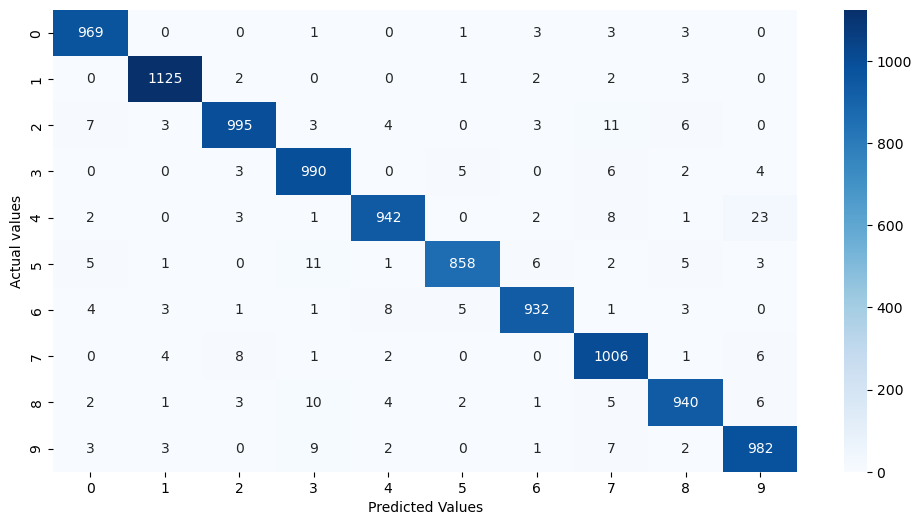

Classification report: 

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.96      0.98      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [48]:
# metric evaluation
cm = confusion_matrix(actual_classes, predicted_classes)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.ylabel('Actual values', fontsize = 10)
plt.xlabel('Predicted Values', fontsize = 10)
plt.show()

print(f'Classification report: \n\n{classification_report(actual_classes, predicted_classes)}')